In [ ]:
import os
import copy
import dataclasses
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [1]:
def dataclass_to_flat_dict(args):
    """
    Converts a tyro dataclass or dict to a flat dictionary.
    """
    flat = {}
    for k, v in vars(args).items():
        if v is None or isinstance(v, (int, float, str, bool, list, tuple)):
            flat[k] = v
        else:
            assert dataclasses.is_dataclass(v), f"Expected dataclass for field {k}, got {type(v)}"
            nested = dataclass_to_flat_dict(v)
            for nk, nv in nested.items():
                flat[f"{k}.{nk}"] = nv
    return flat


def create_commands(cfgs, prefix=None, out_file=None):
    """
    Given a list of dataclass instances or dicts, produce aligned command strings.
    """
    if len(cfgs) == 0:
        return []
    if dataclasses.is_dataclass(cfgs[0]):
        cfgs = [dataclass_to_flat_dict(c) for c in cfgs]
    keys = set(cfgs[0].keys())
    assert all(set(c.keys()) == keys for c in cfgs), "All configs must have identical keys"
    
    arg_lists = []
    for cfg in cfgs:
        parts = []
        for k in sorted(keys):
            v = cfg[k]
            if isinstance(v, list):
                joined = ' '.join(f'"{iv}"' if isinstance(iv, str) else str(iv) for iv in v)
                parts.append(f"--{k} {joined}")
            else:
                val = f'"{v}"' if isinstance(v, str) else str(v)
                parts.append(f"--{k}={val}")
        arg_lists.append(parts)
    
    n_cols = len(arg_lists[0])
    widths = [max(len(arg_lists[i][j]) for i in range(len(arg_lists))) for j in range(n_cols)]
    lines = []
    for parts in arg_lists:
        padded = [parts[j].ljust(widths[j]) for j in range(n_cols)]
        cmd = ' '.join(padded)
        if prefix:
            cmd = f"{prefix} {cmd}"
        lines.append(cmd)
    
    if out_file:
        os.makedirs(os.path.dirname(out_file), exist_ok=True)
        with open(out_file, 'w') as f:
            f.write("\n".join(lines) + "\n")
    return lines

In [2]:
from param_mlp import *

base = ParamMLPArgs()
base.n_iters = 50000
base.log_every = 1000

dt_list = [1, 2, 4, 8, 16, 32, 64]
seeds = list(range(3))

configs = []
for seed in seeds:
    for dt in dt_list:
        cfg = copy.deepcopy(base)
        cfg.seed = seed
        cfg.data.dt = dt
        cfg.save_dir = f"data/run_0/dt={dt}_seed={seed}"
        configs.append(cfg)

cmds = create_commands(configs, prefix="python param_mlp.py", out_file="science_scripts/run_param_mlp.sh")
for c in cmds:
    print(c)

python param_mlp.py --data.dt=1  --data.gol_params_max=262144 --data.grid_size=64 --data.t_end=64 --data.t_start=32 --log_every=1000 --model.hidden_dims 128 128 --model.output_dim=512 --n_iters=50000 --opt.batch_size=32 --opt.clip_grad_norm=1.0 --opt.learning_rate=0.0003 --opt.weight_decay=1e-05 --save_dir="data/run/dt=1_seed=0"  --seed=0
python param_mlp.py --data.dt=2  --data.gol_params_max=262144 --data.grid_size=64 --data.t_end=64 --data.t_start=32 --log_every=1000 --model.hidden_dims 128 128 --model.output_dim=512 --n_iters=50000 --opt.batch_size=32 --opt.clip_grad_norm=1.0 --opt.learning_rate=0.0003 --opt.weight_decay=1e-05 --save_dir="data/run/dt=2_seed=0"  --seed=0
python param_mlp.py --data.dt=4  --data.gol_params_max=262144 --data.grid_size=64 --data.t_end=64 --data.t_start=32 --log_every=1000 --model.hidden_dims 128 128 --model.output_dim=512 --n_iters=50000 --opt.batch_size=32 --opt.clip_grad_norm=1.0 --opt.learning_rate=0.0003 --opt.weight_decay=1e-05 --save_dir="data/run/

In [6]:
df = []
for cfg in configs:
    history = util.load_pkl(cfg.save_dir, "history")
    final_loss = history[-1] if history else None
    record = {
        'dt': cfg.data.dt,
        'seed': cfg.seed,
        'final_loss': float(final_loss) if final_loss is not None else None,
        'gol_params_max': cfg.data.gol_params_max
    }
    df.append(record)

df = pd.DataFrame(df)

In [7]:
df

,dt,seed,final_loss,gol_params_max
0,1,0,0.000117,262144
1,2,0,0.000114,262144
2,4,0,0.000118,262144
3,8,0,0.000112,262144
4,16,0,0.000118,262144
5,32,0,0.000118,262144
6,64,0,0.000119,262144
7,1,1,0.000107,262144
8,2,1,0.000134,262144
9,4,1,0.000133,262144


Results summary:
Number of completed experiments: 21
dt values: [np.int64(1), np.int64(2), np.int64(4), np.int64(8), np.int64(16), np.int64(32), np.int64(64)]
Mean final loss by dt:
  dt=1: 0.0001 ± 0.0000 (n=3)
  dt=2: 0.0001 ± 0.0000 (n=3)
  dt=4: 0.0001 ± 0.0000 (n=3)
  dt=8: 0.0001 ± 0.0000 (n=3)
  dt=16: 0.0001 ± 0.0000 (n=3)
  dt=32: 0.0001 ± 0.0000 (n=3)
  dt=64: 0.0001 ± 0.0000 (n=3)


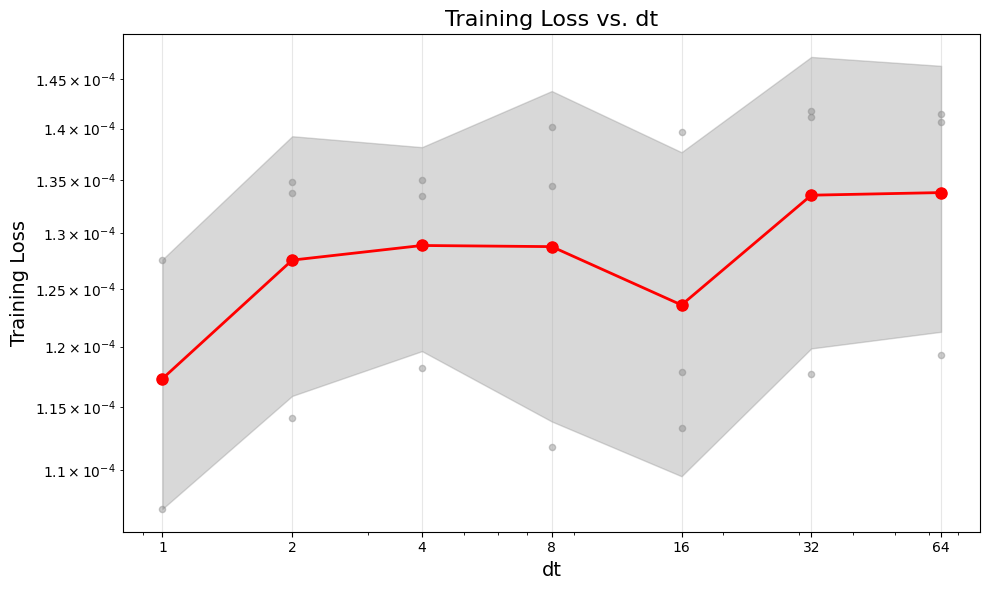

In [13]:
plt.figure(figsize=(10, 6))
    
dt_stats = df.groupby('dt')['final_loss'].agg(['mean', 'std']).reset_index()

plt.plot(dt_stats['dt'], dt_stats['mean'], color='red', marker='o', markersize=8, linewidth=2, label='Mean')
plt.fill_between(dt_stats['dt'], dt_stats['mean'] - dt_stats['std'], dt_stats['mean'] + dt_stats['std'], color='gray', alpha=0.3, label='±1 std')
plt.scatter(dt_stats['dt'], dt_stats['mean'], color='red', s=50, zorder=5)
plt.scatter(df.dt, df.final_loss, color='gray', s=20, alpha=0.4)

plt.xscale('log')
plt.yscale('log')
plt.xticks(dt_list, dt_list)
plt.xlabel("dt", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.title("Training Loss vs. dt", fontsize=16)
plt.grid(True, alpha=0.3)

print(f"# of experiments: {len(df)}")
print(f"dt values: {sorted(df.dt.unique())}")
print(f"Mean final loss by dt:")
for dt in sorted(df.dt.unique()):
    dt_data = df[df.dt == dt]
    print(f"  dt={dt}: {dt_data.final_loss.mean():.4f} ± {dt_data.final_loss.std():.4f} (n={len(dt_data)})")

plt.tight_layout()
plt.savefig("params_to_clip_vector_loss.png")
plt.show()

Results summary:
Number of completed experiments: 21
dt values: [np.int64(1), np.int64(2), np.int64(4), np.int64(8), np.int64(16), np.int64(32), np.int64(64)]
Mean final loss by dt:
  dt=1: 0.0001 ± 0.0000 (n=3)
  dt=2: 0.0001 ± 0.0000 (n=3)
  dt=4: 0.0001 ± 0.0000 (n=3)
  dt=8: 0.0001 ± 0.0000 (n=3)
  dt=16: 0.0001 ± 0.0000 (n=3)
  dt=32: 0.0001 ± 0.0000 (n=3)
  dt=64: 0.0001 ± 0.0000 (n=3)


<Figure size 1000x600 with 0 Axes>

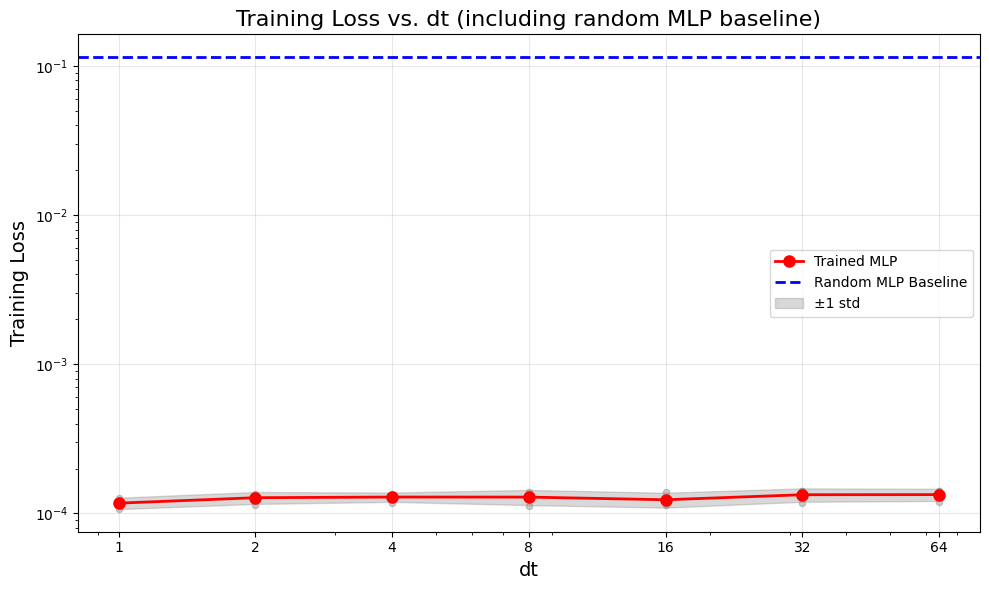

In [17]:
plt.figure(figsize=(10, 6))
    
dt_stats = df.groupby('dt')['final_loss'].agg(['mean', 'std']).reset_index()
    
# Calculate baseline loss with random MLP
sample_cfg = configs[0]
rng = PRNGKey(42)  # Fixed seed for reproducible baseline
mlp = ParamMLP(hidden_dims=sample_cfg.model.hidden_dims, output_dim=sample_cfg.model.output_dim)
        
substrate = GameOfLife(grid_size=sample_cfg.data.grid_size)
fm = create_foundation_model('clip')
dts = jnp.array([sample_cfg.data.dt] if isinstance(sample_cfg.data.dt, int) else sample_cfg.data.dt)
dt_max = int(dts.max())
rollout_fn = jax.jit(partial(
    rollout_simulation,
    s0=None, substrate=substrate, fm=None,
    rollout_steps=sample_cfg.data.t_end + dt_max,
    time_sampling='video', img_size=None,
    return_state=True
))
        
num_bits = int(jnp.ceil(jnp.log2(sample_cfg.data.gol_params_max)))
        
# Generate real data samples, just as in training
def gen_baseline_sample(rng):
    rng, sub = split(rng)
    pid = jax.random.randint(sub, (), 0, sample_cfg.data.gol_params_max, dtype=jnp.int32)
    rng, sub = split(rng)
    state = rollout_fn(sub, pid)['state']
    rng, sub = split(rng)
    t0 = jax.random.randint(sub, (), sample_cfg.data.t_start, sample_cfg.data.t_end, dtype=jnp.int32)
    rng, sub = split(rng)
    dt_id = jax.random.randint(sub, (), 0, len(dts), dtype=jnp.int32)
    x1 = state[t0 + dts[dt_id]]
    bits = ((pid[..., None] >> jnp.arange(num_bits)) & 1).astype(jnp.float32)
    return bits, x1, pid
        
rng, batch_rng = split(rng)
batch_rngs = jax.random.split(batch_rng, 32)  # Small batch for baseline
baseline_batch = jax.vmap(gen_baseline_sample)(batch_rngs)
bits_batch, states_batch, pids_batch = baseline_batch
render_fn = jax.vmap(lambda state, pid: substrate.render_state(state, params=pid, img_size=224))
imgs_batch = render_fn(states_batch, pids_batch)
embeds_batch = jax.vmap(fm.embed_img)(imgs_batch)
        
# Initialize random MLP params
dummy_input = jnp.zeros((32, num_bits))
random_params = mlp.init(rng, dummy_input)['params']
random_preds = mlp.apply({'params': random_params}, bits_batch)
baseline_loss = float(jnp.mean((random_preds - embeds_batch)**2))
    
plt.plot(dt_stats['dt'], dt_stats['mean'], color='red', marker='o', markersize=8, linewidth=2, label='Trained MLP')
plt.axhline(y=baseline_loss, color='blue', linestyle='--', linewidth=2, label='Random MLP Baseline')
plt.fill_between(dt_stats['dt'], dt_stats['mean'] - dt_stats['std'], dt_stats['mean'] + dt_stats['std'], color='gray', alpha=0.3, label='±1 std')
plt.scatter(dt_stats['dt'], dt_stats['mean'], color='red', s=50, zorder=5)
plt.scatter(df.dt, df.final_loss, color='gray', s=20, alpha=0.4)
    
plt.legend()
plt.xscale('log')
plt.yscale('log')
plt.xticks(dt_list, dt_list)
plt.xlabel("dt", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.title("Training Loss vs. dt (including random MLP baseline)", fontsize=16)
plt.grid(True, alpha=0.3)

print(f"# of experiments: {len(df)}")
print(f"dt values: {sorted(df.dt.unique())}")
print(f"Mean final loss by dt:")
for dt in sorted(df.dt.unique()):
    dt_data = df[df.dt == dt]
    print(f"  dt={dt}: {dt_data.final_loss.mean():.4f} ± {dt_data.final_loss.std():.4f} (n={len(dt_data)})")
    
plt.tight_layout()
plt.savefig("params_to_clip_vector_loss_with_baseline.png")
plt.show()